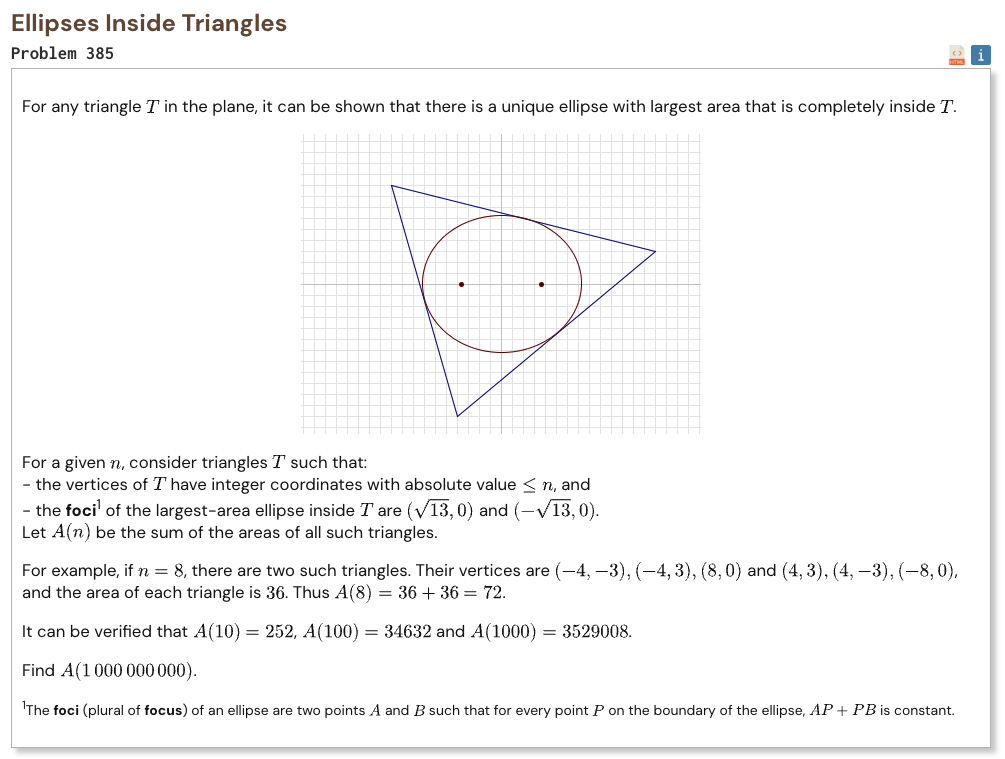

## Initial approach

* the largest ellipse is the Steiner inellipse and its center is the triangle centroid
* since the two foci are symmetric around the origin the triangle centroid must also be the origin
* use Marden’s theorem to convert the focus condition into equations between the three complex vertices
* reduce these equations into a small set of Pell equations
* generate every solution by multiplying by the fundamental Pell unit two plus square root of three
* convert each Pell solution back into three integer coordinate vertices
* keep only triangles whose coordinates stay inside the given limit
* remove duplicates and add each triangle area

In [1]:
from math import gcd


PELL_SEEDS = {
    468: [(24, 6), (30, 12)],
    117: [(12, 3), (15, 6)],
    36: [(6, 0)],
    9: [(3, 0)]
}


def pell_step(s, t):
    return 2 * s + 3 * t, s + 2 * t


def find_directions():
    directions = []

    for m in range(-12, 13):
        for n in range(-21, 22):
            if m == 0 and n == 0:
                continue

            if gcd(abs(m), abs(n)) != 1:
                continue

            d = n * n + 3 * m * m

            if 468 % d != 0:
                continue

            k = 468 // d

            if k in PELL_SEEDS:
                directions.append((m, n, d, k))

    return directions


def calculate(limit):
    directions = find_directions()
    triangles = set()
    area_numerator = 0

    for m, n, d, k in directions:
        for initial_s, initial_t in PELL_SEEDS[k]:
            s = initial_s
            t = initial_t

            while max(s, t) <= 6 * limit + 10:
                if s != 0 and t != 0:
                    for signed_s in (s, -s):
                        for signed_t in (t, -t):
                            if signed_s * n % 3 != 0:
                                continue

                            a = signed_s * m
                            b = -signed_t * n
                            c = signed_s * n // 3
                            e = signed_t * m

                            if (a + c) % 2 != 0:
                                continue

                            if (b + e) % 2 != 0:
                                continue

                            x1 = (a + c) // 2
                            y1 = (b + e) // 2

                            x2 = (c - a) // 2
                            y2 = (e - b) // 2

                            x3 = -c
                            y3 = -e

                            coordinates = (
                                x1, y1,
                                x2, y2,
                                x3, y3
                            )

                            if max(abs(value) for value in coordinates) > limit:
                                continue

                            triangle = tuple(sorted((
                                (x1, y1),
                                (x2, y2),
                                (x3, y3)
                            )))

                            if triangle in triangles:
                                continue

                            triangles.add(triangle)
                            area_numerator += d * abs(s * t)

                s, t = pell_step(s, t)

    return area_numerator // 4


assert calculate(8) == 72
assert calculate(10) == 252
assert calculate(100) == 34632
assert calculate(1000) == 3529008

In [2]:
%%time
result = calculate(10 ** 9)
print("Result:", result)

Result: 3776957309612153700
CPU times: user 3.71 ms, sys: 106 μs, total: 3.82 ms
Wall time: 3.78 ms
